# Домашнее задание 1

* en1k из корпуса WikIR (`documents.csv`) — уже очищенное, токенизированное и приведённое к нижнему регистру

* Стоп‑слова: `stopwords.txt`

In [2]:
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DATA_PATH = 'documents.csv'
STOPWORDS_PATH = 'stopwords.txt'

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

/Users/smakov/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Данные


In [ ]:
def load_documents(path):
    docs = []
    with open(path, 'r', encoding='utf-8') as f:
        header = next(f)

        for line in f:
            idx = line.find(',')
            if idx == -1:
                continue
            docs.append(line[idx + 1:].rstrip('\n'))
    return docs

documents = load_documents(DATA_PATH)
print(f'Loaded {len(documents):,} documents')
print('Example:', documents[0][:200], '...')

Loaded 369,721 documents
Example: it was used in landing craft during world war ii and is used today in private boats and training facilities the 6 71 is an inline six cylinder diesel engine the 71 refers to the displacement in cubic  ...


In [5]:
with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
    STOPWORDS = {w.strip() for w in f if w.strip()}
print(f'{len(STOPWORDS)} stopwords loaded. Sample:', sorted(STOPWORDS)[:10])

127 stopwords loaded. Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and']


## 1. Базовая статистика коллекции

За один проход накапливаем:

* число документов
* общее число вхождений слов (размер коллекции в словах)
* длину каждого документа (для среднего)
* частотный счётчик слов (используется и в дальнейшем)
* суммарное число символов всех вхождений слов (для средней длины слова)

In [ ]:
word_freq = Counter()
doc_lengths = []
total_chars = 0  # sum over occurrences (weighted by frequency)

for text in tqdm(documents, desc='Tokenising'):
    tokens = text.split()
    doc_lengths.append(len(tokens))
    word_freq.update(tokens)

# Derive the character total from the frequency list (cheaper than per-token).
total_chars = sum(len(w) * c for w, c in word_freq.items())

num_docs = len(documents)
num_tokens = sum(doc_lengths)
num_types = len(word_freq)
avg_doc_len = num_tokens / num_docs
avg_word_len = total_chars / num_tokens              
avg_type_len = sum(len(w) for w in word_freq) / num_types  # one count per type

print(f'# documents                : {num_docs:>12,}')
print(f'Collection size in words   : {num_tokens:>12,}')
print(f'Avg document length (words): {avg_doc_len:>12.2f}')
print(f'# unique words (types)     : {num_types:>12,}')
print(f'Avg word length (occurr.)  : {avg_word_len:>12.2f}')
print(f'Avg type length (unique)   : {avg_type_len:>12.2f}')

Tokenising: 100%|██████████| 369721/369721 [00:06<00:00, 53742.54it/s]


# documents                :      369,721
Collection size in words   :   73,093,729
Avg document length (words):       197.70
# unique words (types)     :      794,568
Avg word length (occurr.)  :         4.80
Avg type length (unique)   :         7.71


## 2. Список частот слов

### 2.1 Построение списка частот

In [9]:
freq_list = word_freq.most_common()
print(f'Top-30 most frequent words (rank, word, count):')
for rank, (w, c) in enumerate(freq_list[:30], 1):
    marker = '*' if w in STOPWORDS else ' '
    print(f'{rank:>3} {marker} {w:<10} {c:>12,}')
print("\n('*' marks words that are in the stopword list)")

Top-30 most frequent words (rank, word, count):
  1 * the           5,311,943
  2 * of            2,532,382
  3 * in            2,355,417
  4 * and           2,231,007
  5 * a             1,557,760
  6 * to            1,407,261
  7 * was           1,078,183
  8 * he              685,303
  9 * is              676,829
 10 * as              661,622
 11 * for             616,110
 12 * on              610,583
 13 * with            535,843
 14 * by              526,627
 15 * s               497,472
 16 * at              482,839
 17 * his             440,633
 18 * from            432,326
 19 * it              398,308
 20 * that            306,808
 21 * an              279,228
 22 * which           221,057
 23   first           217,204
 24 * are             206,921
 25 * were            205,684
 26 * has             195,167
 27   also            186,055
 28 * she             184,297
 29 * after           166,616
 30 * its             161,439

('*' marks words that are in the stopword list)


### 2.2 Анализ стоп‑слов

In [10]:
stopword_occurrences = sum(c for w, c in word_freq.items() if w in STOPWORDS)
stopword_types_seen  = sum(1 for w in word_freq if w in STOPWORDS)

top40_words = [w for w, _ in freq_list[:40]]
top40_in_stop = [w for w in top40_words if w in STOPWORDS]
top40_not_in_stop = [w for w in top40_words if w not in STOPWORDS]

print(f'Stopword occurrences in collection : {stopword_occurrences:,} '
      f'({100 * stopword_occurrences / num_tokens:.2f}% of all tokens)')
print(f'Stopword types present in vocab    : {stopword_types_seen}/{len(STOPWORDS)}')
print()
print(f'Top-40 words in the stopword list ({len(top40_in_stop)}):')
print(' ', ', '.join(top40_in_stop))
print(f'\nTop-40 words NOT in the stopword list ({len(top40_not_in_stop)}):')
print(' ', ', '.join(top40_not_in_stop))

Stopword occurrences in collection : 29,387,785 (40.21% of all tokens)
Stopword types present in vocab    : 127/127

Top-40 words in the stopword list (35):
  the, of, in, and, a, to, was, he, is, as, for, on, with, by, s, at, his, from, it, that, an, which, are, were, has, she, after, its, this, her, had, or, be, their, who

Top-40 words NOT in the stopword list (5):
  first, also, one, new, two


Список стоп‑слов покрывает наиболее частотные слова

Тем не менее ряд очень частотных слов в список не входит, но является хорошим кандидатом в стоп‑слова: союзы, предлоги, артикли.

### 2.3 Закон Ципфа — ранг vs. частота в коллекции (лог‑лог)

Fitted Zipf slope (ranks 10..10000): -1.105  (classical value ≈ -1)


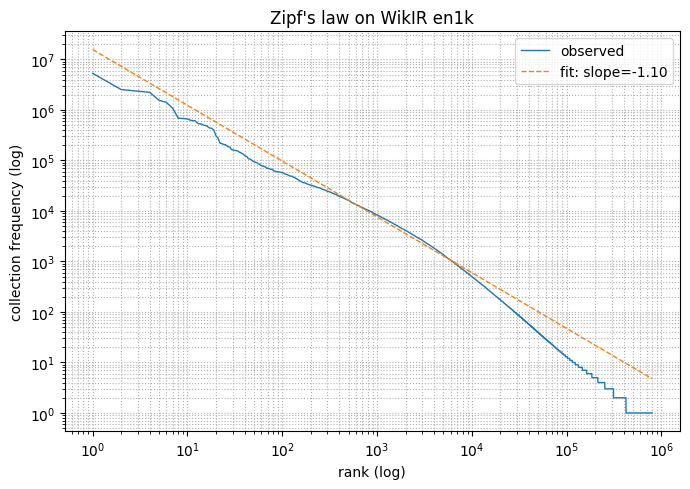

In [11]:
ranks = np.arange(1, len(freq_list) + 1)
counts = np.array([c for _, c in freq_list])

mask = (ranks >= 10) & (ranks <= 10000)
b, a = np.polyfit(np.log10(ranks[mask]), np.log10(counts[mask]), 1)
print(f'Fitted Zipf slope (ranks 10..10000): {b:.3f}  (classical value ≈ -1)')

plt.figure(figsize=(7, 5))
plt.loglog(ranks, counts, lw=1, label='observed')
plt.loglog(ranks, 10 ** (a + b * np.log10(ranks)), '--', lw=1,
           label=f'fit: slope={b:.2f}')
plt.xlabel('rank (log)')
plt.ylabel('collection frequency (log)')
plt.title("Zipf's law on WikIR en1k")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 Закон Хипса — рост словаря


Проходим по потоку токенов в порядке коллекции и в логарифмически распределённых точках фиксируем пары (число просмотренных токенов, число увиденных уникальных типов).

Heaps pass: 100%|██████████| 369721/369721 [00:11<00:00, 31055.04it/s]


Heaps fit: V ≈ 9.26 · N^0.634  (typical β ∈ [0.4, 0.6])


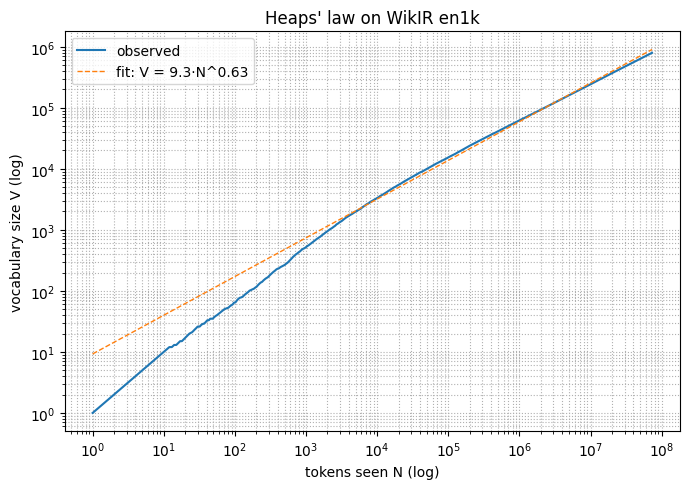

In [12]:
sample_points = np.unique(np.geomspace(1, num_tokens, num=400).astype(np.int64))
sample_points_set = set(sample_points.tolist())

seen = set()
xs, ys = [], []
n_tokens_seen = 0

for text in tqdm(documents, desc='Heaps pass'):
    for w in text.split():
        n_tokens_seen += 1
        seen.add(w)
        if n_tokens_seen in sample_points_set:
            xs.append(n_tokens_seen)
            ys.append(len(seen))

if not xs or xs[-1] != n_tokens_seen:
    xs.append(n_tokens_seen); ys.append(len(seen))

xs = np.array(xs); ys = np.array(ys)

mask = xs >= 1000
beta, logK = np.polyfit(np.log10(xs[mask]), np.log10(ys[mask]), 1)
K = 10 ** logK
print(f'Heaps fit: V ≈ {K:.2f} · N^{beta:.3f}  (typical β ∈ [0.4, 0.6])')

plt.figure(figsize=(7, 5))
plt.loglog(xs, ys, lw=1.5, label='observed')
plt.loglog(xs, K * xs ** beta, '--', lw=1,
           label=f'fit: V = {K:.1f}·N^{beta:.2f}')
plt.xlabel('tokens seen N (log)')
plt.ylabel('vocabulary size V (log)')
plt.title("Heaps' law on WikIR en1k")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Биграммы

### 3.1 Построение списка частот биграмм

In [13]:
bigram_freq = Counter()

for text in tqdm(documents, desc='Bigrams'):
    toks = text.split()
    if len(toks) < 2:
        continue
    bigram_freq.update(zip(toks, toks[1:]))

num_bigram_tokens = sum(bigram_freq.values())
num_unique_bigrams = len(bigram_freq)
print(f'Bigram occurrences     : {num_bigram_tokens:>14,}')
print(f'Unique bigrams (types) : {num_unique_bigrams:>14,}')

Bigrams: 100%|██████████| 369721/369721 [00:30<00:00, 12313.82it/s]


Bigram occurrences     :     72,724,008
Unique bigrams (types) :     12,993,004


### 3.2 Топ списка и критерии включения в словарь

In [14]:
top_bigrams = bigram_freq.most_common(40)
print('Top-40 bigrams:')
for i, ((w1, w2), c) in enumerate(top_bigrams, 1):
    both_stop = (w1 in STOPWORDS) and (w2 in STOPWORDS)
    any_stop  = (w1 in STOPWORDS) or (w2 in STOPWORDS)
    tag = 'STOP-STOP' if both_stop else ('has-stop ' if any_stop else 'content  ')
    print(f'{i:>3}. {tag}  {w1} {w2:<12} {c:>10,}')

Top-40 bigrams:
  1. STOP-STOP  of the             768,320
  2. STOP-STOP  in the             546,863
  3. STOP-STOP  to the             256,451
  4. STOP-STOP  at the             201,351
  5. STOP-STOP  and the             170,394
  6. STOP-STOP  on the             169,708
  7. STOP-STOP  he was             163,554
  8. STOP-STOP  as a               163,073
  9. STOP-STOP  for the             159,502
 10. STOP-STOP  by the             130,810
 11. STOP-STOP  with the             120,118
 12. STOP-STOP  from the             115,219
 13. has-stop   the first           104,264
 14. STOP-STOP  it was             101,387
 15. STOP-STOP  as the              96,915
 16. STOP-STOP  it is               95,880
 17. STOP-STOP  is a                82,161
 18. STOP-STOP  was a                78,342
 19. STOP-STOP  in a                76,786
 20. has-stop   one of               70,278
 21. STOP-STOP  was the              69,881
 22. STOP-STOP  of a                69,345
 23. STOP-STOP  with a      

* Какие биграммы стоит включать как записи словаря?

Верх списка целиком занята парами стоп‑слов вида of the, in the, to the, ... — оба слова уже присутствуют как униграммы, и сама пара не несёт дополнительного смыслового содержания, поэтому включать их в инвертированный индекс не нужно.

Имеет смысл сохранять коллокации — пары, которые встречаются гораздо чаще, чем это предсказывает произведение частот униграмм. Простая и общепринятая формализация:

1. Ни один из токенов не является стоп‑словом
2. Минимальная частота
3. PMI или log‑likelihood ratio выше порога

In [15]:
MIN_BIGRAM_COUNT = 50

# log p(w) = log c(w) - log N
log2_N_uni = math.log2(num_tokens)
log2_N_bi  = math.log2(num_bigram_tokens)

candidates = []
for (w1, w2), c in bigram_freq.items():
    if c < MIN_BIGRAM_COUNT:
        continue
    if w1 in STOPWORDS or w2 in STOPWORDS:
        continue
    pmi = (math.log2(c) - log2_N_bi) - (math.log2(word_freq[w1]) - log2_N_uni) \
                                     - (math.log2(word_freq[w2]) - log2_N_uni)
    candidates.append(((w1, w2), c, pmi))

candidates.sort(key=lambda x: x[1], reverse=True)
print(f'Bigrams passing the filter (count >= {MIN_BIGRAM_COUNT}, no stopwords): '
      f'{len(candidates):,}')
print()
print(f'{"bigram":<28}{"count":>10}{"PMI":>8}')
for (w1, w2), c, pmi in candidates[:25]:
    print(f'{w1+" "+w2:<28}{c:>10,}{pmi:>8.2f}')


Bigrams passing the filter (count >= 50, no stopwords): 35,167

bigram                           count     PMI
united states                   48,952    9.78
new york                        38,477    8.94
high school                     29,895    8.25
world war                       20,915    8.38
war ii                          10,432    9.03
york city                       10,401    7.90
los angeles                     10,042   12.58
two years                        9,013    5.78
new zealand                      8,764    9.03
years later                      7,412    6.25
best known                       7,391    7.68
also known                       7,198    5.26
united kingdom                   6,924    9.19
19th century                     6,721   10.58
first time                       6,640    4.56
state university                 6,199    5.92
air force                        6,145   10.24
took place                       6,045    8.68
year old                         6,025    7

## 4. Морфологическая обработка


Портер Стеммер и токенизатор BERT не зависят от контекста, поэтому кэшируем их вывод на словарь и взвешиваем по исходным частотам — полная коллекция, быстро. Лемматизатор spaсy зависит от контекста, поэтому запускаем его на случайной выборке из 10 000 документов.

### 4.1 Портер Стеммер — полная коллекция

In [16]:
from nltk.stem.porter import PorterStemmer

porter = PorterStemmer()
porter_map = {}
for w in tqdm(word_freq, desc='Porter-stem vocab'):
    porter_map[w] = porter.stem(w)

stem_freq = Counter()
porter_total_tokens = 0
porter_total_chars  = 0
for w, c in word_freq.items():
    s = porter_map[w]
    stem_freq[s] += c
    porter_total_tokens += c                 # stemming is 1-to-1 per token
    porter_total_chars  += len(s) * c

porter_stats = {
    'tokens'          : porter_total_tokens,
    'types'           : len(stem_freq),
    'avg_token_len'   : porter_total_chars / porter_total_tokens,
    'avg_type_len'    : sum(len(s) for s in stem_freq) / len(stem_freq),
    'avg_doc_len'     : porter_total_tokens / num_docs,
}
porter_stats

Porter-stem vocab: 100%|██████████| 794568/794568 [00:07<00:00, 105392.95it/s]


{'tokens': 73093729,
 'types': 684579,
 'avg_token_len': 4.264522241025629,
 'avg_type_len': 7.341918171606199,
 'avg_doc_len': 197.69969517555128}

### 4.2 Лемматизация spaсy — случайная выборка документов

Предварительно токенизируем и подаём в пайплайн spacy объекты `Doc`

Отключаем компоненты parser и NER, оставляя только tagger + attribute ruler + lemmatizer

In [17]:
import spacy
from spacy.tokens import Doc

SAMPLE_SIZE = 10_000
sample_idx = sorted(random.Random(RNG_SEED).sample(range(num_docs), SAMPLE_SIZE))
sample_tokens = [documents[i].split() for i in sample_idx]

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print('spaCy pipeline:', nlp.pipe_names)

spaCy pipeline: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


In [14]:
def pretokenised_docs(token_lists, vocab):
    for toks in token_lists:
        yield Doc(vocab, words=toks)

spacy_tokens_total = 0
spacy_chars_total  = 0
spacy_lemma_freq   = Counter()
spacy_doc_lengths  = []

batch = 64
for doc in tqdm(nlp.pipe(pretokenised_docs(sample_tokens, nlp.vocab),
                         batch_size=batch),
                total=len(sample_tokens), desc='spaCy lemmatize'):
    lemmas = [t.lemma_ for t in doc]
    spacy_doc_lengths.append(len(lemmas))
    spacy_tokens_total += len(lemmas)
    spacy_chars_total  += sum(len(l) for l in lemmas)
    spacy_lemma_freq.update(lemmas)

spacy_stats = {
    'tokens'        : spacy_tokens_total,
    'types'         : len(spacy_lemma_freq),
    'avg_token_len' : spacy_chars_total / spacy_tokens_total,
    'avg_type_len'  : sum(len(l) for l in spacy_lemma_freq) / len(spacy_lemma_freq),
    'avg_doc_len'   : spacy_tokens_total / len(sample_tokens),
    '_sample_size'  : len(sample_tokens),
}
spacy_stats

spaCy lemmatize: 100%|██████████| 10000/10000 [01:54<00:00, 87.37it/s]


{'tokens': 1976548,
 'types': 83046,
 'avg_token_len': 4.586870645185445,
 'avg_type_len': 7.107253811140813,
 'avg_doc_len': 197.6548,
 '_sample_size': 10000}

### 4.3 BERT WordPiece токенизатор — полная коллекция

`bert-base-uncased` токенизатор не зависит от контекста, поэтому — точно так же, как и для Портера - токенизируем каждое уникальное слово словаря один раз и накапливаем статистики, взвешенные по частотам

In [15]:
from transformers import AutoTokenizer

bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
assert bert_tok.is_fast

vocab_words = list(word_freq.keys())
bert_pieces_per_word = {}
CHUNK = 10_000
for i in tqdm(range(0, len(vocab_words), CHUNK), desc='BERT vocab'):
    batch = vocab_words[i:i + CHUNK]
    # add_special_tokens=False -> no [CLS]/[SEP]
    enc = bert_tok(batch, add_special_tokens=False)['input_ids']
    for w, ids in zip(batch, enc):
        bert_pieces_per_word[w] = bert_tok.convert_ids_to_tokens(ids)

bert_piece_freq = Counter()
bert_total_tokens = 0
bert_total_chars  = 0
for w, c in word_freq.items():
    pieces = bert_pieces_per_word[w]
    bert_total_tokens += c * len(pieces)
    bert_total_chars  += c * sum(len(p) for p in pieces)
    for p in pieces:
        bert_piece_freq[p] += c

bert_stats_full = {
    'tokens'        : bert_total_tokens,
    'types'         : len(bert_piece_freq),
    'avg_token_len' : bert_total_chars / bert_total_tokens,
    'avg_type_len'  : sum(len(p) for p in bert_piece_freq) / len(bert_piece_freq),
    'avg_doc_len'   : bert_total_tokens / num_docs,
}
bert_stats_full

BERT vocab: 100%|██████████| 80/80 [00:19<00:00,  4.15it/s]


{'tokens': 81185427,
 'types': 27528,
 'avg_token_len': 4.5165385777918,
 'avg_type_len': 6.633500435919791,
 'avg_doc_len': 219.5856524243957}

### 4.4 Сводная таблица

In [16]:
rows = [
    ('original', num_tokens,              num_types,            avg_word_len,
                 avg_type_len,            avg_doc_len,          'full collection'),
    ('porter',   porter_stats['tokens'],  porter_stats['types'], porter_stats['avg_token_len'],
                 porter_stats['avg_type_len'], porter_stats['avg_doc_len'], 'full collection'),
    ('spacy',    spacy_stats['tokens'],   spacy_stats['types'],  spacy_stats['avg_token_len'],
                 spacy_stats['avg_type_len'],  spacy_stats['avg_doc_len'],  f'sample of {SAMPLE_SIZE:,} docs'),
    ('bert-wp',  bert_stats_full['tokens'], bert_stats_full['types'], bert_stats_full['avg_token_len'],
                 bert_stats_full['avg_type_len'], bert_stats_full['avg_doc_len'], 'full collection'),
]

print(f'{"method":<10}{"tokens":>14}{"types":>12}{"avg tok":>10}{"avg type":>10}{"avg doc":>10}  scope')
for name, n, v, atl, atyl, adl, scope in rows:
    print(f'{name:<10}{n:>14,}{v:>12,}{atl:>10.2f}{atyl:>10.2f}{adl:>10.2f}  {scope}')


method            tokens       types   avg tok  avg type   avg doc  scope
original      73,093,729     794,568      4.80      7.71    197.70  full collection
porter        73,093,729     684,579      4.26      7.34    197.70  full collection
spacy          1,976,548      83,046      4.59      7.11    197.65  sample of 10,000 docs
bert-wp       81,185,427      27,528      4.52      6.63    219.59  full collection


## Выводы

* Портер Стеммер сохраняет число токенов (1 токен на входе - 1 токен на выходе), но схлопывает поверхностные в общий стем, поэтому размер словаря резко падает, а средняя длина токена немного уменьшается (за счёт удаления окончаний)

* Лемматизация spacy также сохраняет соотношение 1:1 на уровне токенов, но обычно даёт меньше типов, чем стеммер Портера, потому что лучше обрабатывает нерегулярные формы (`went - go`, `children - child`). Длина больше, чем после Портера, потому что леммы — это слова, а не усечённые стемы

* BERT WordPiece увеличивает число токенов (OOV‑слова дробятся на несколько subword), но резко сжимает словарь. Средняя длина токена меньше исходной, потому что длинные редкие слова режутся на короткие фрагменты